In [1]:
%load_ext autoreload
%autoreload 2
# Cell 1 in your Jupyter Notebook
import sys
import os

# Point Python to the main icetmosphere folder
sys.path.append(os.path.abspath('..'))

In [2]:
from atm_tools import alpha_specific_function
from class_and_spt_emission import compute_T_RJ_ice2, compute_T_RJ_ice_CLASS1, compute_depolarization_factor
from scipy import constants
import pycraf
from astropy import units as u

import matplotlib.pyplot as plt
import numpy as np

# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})

In [3]:
altitudes = np.linspace(1, 10000, 500) #m
altitudes = altitudes +4999 #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en hPa
dz = np.diff(altitudes) # Shape: (len(altitudes)-1,)
frequency_ghz = np.arange(1, 999, 3) # GHz   
frequency = frequency_ghz * 1e9 # Hz

pi = constants.pi 
c = constants.c
rho_ice = 917 #kg/m^3

elevation = 45 #degrees
IWP = 1e-3 #kg/m2

layer_bottom = 6000  # Bottom of the ice cloud layer in meters (example)
layer_top = 7000     # Top of the ice cloud layer in meters (example)
cloud_thickness = layer_top - layer_bottom # Thickness of the ice cloud layer in meters

r_eq = np.array([30e-6]) # equivalet radius in meters

# 3. Calculate d(IWP)/dz (which is the Ice Water Content)
# For a uniform cloud, it is just Total IWP / thickness
IWC_constant = IWP / cloud_thickness # kg/m^3

# Create the IWC profile (0 everywhere except in the cloud)
IWC_profile = np.where((altitudes >= layer_bottom) & (altitudes <= layer_top), IWC_constant, 0.0)
# Shape of IWC_profile is (Nz,)

# 4. Compute Volume of the crystals for all radii
V = (4.0 / 3.0) * np.pi * r_eq**3 # Shape: (Na,)

# 5. Compute the ice density n(z, r_eq) using Broadcasting
# We use [:, None] to make IWC a column (Nz, 1) 
# We use [None, :] to make V a row (1, Na)
# The result is a 2D grid of shape (Nz, Na)
n = IWC_profile[:, None] / (rho_ice * V[None, :])

#We could normalize PWV to 1 mm

m = np.array([0.1, 0.5, 1, 2, 5, 10])

In [4]:
I_RJ_scattering_tot_earth_curv = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m, stokes_param='I', consider_earth_curvature=True, consider_atmospheric_emission=True
)

I_RJ_scattering_ground_earth_curv = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m, stokes_param='I', consider_earth_curvature=True, consider_atmospheric_emission=False
)


I_RJ_scattering_atmos_earth_curv = I_RJ_scattering_tot_earth_curv - I_RJ_scattering_ground_earth_curv


I_RJ_emission = compute_T_RJ_ice2(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq,
    aspect_ratio=m, process='emission', stokes_param='I'
)

/pscratch/sd/v/valer/atmo3/notebooks/testing_class_ice_emisison/class_and_spt_emission.py:413: RuntimeWarning: overflow encountered in exp
  T_sky = T_mid * (1.0 - np.exp(-tau_above * m_sky))
/pscratch/sd/v/valer/atmo3/notebooks/testing_class_ice_emisison/class_and_spt_emission.py:413: RuntimeWarning: overflow encountered in multiply
  T_sky = T_mid * (1.0 - np.exp(-tau_above * m_sky))


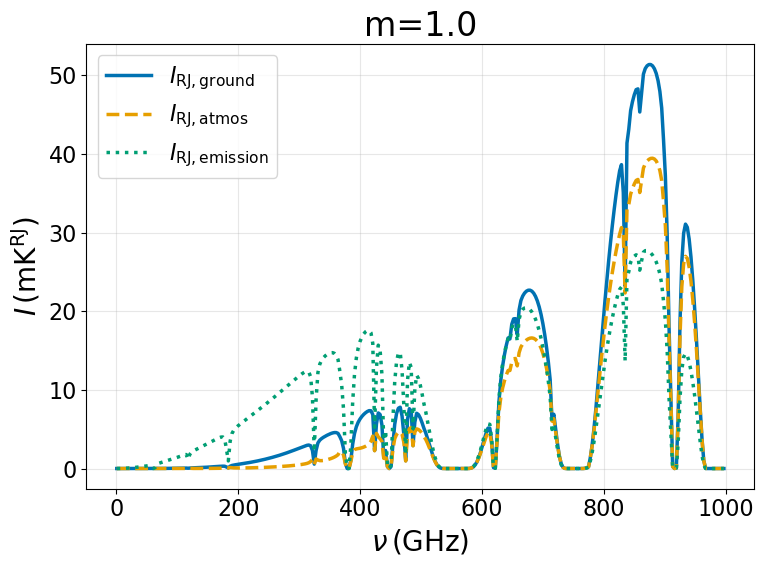

In [21]:
# Plot each effect as a function of frequency for one chosen aspect-ratio index
m_index = 2  # Choose the aspect-ratio index you want to inspect

fig, ax = plt.subplots(figsize=(8, 6))

# High-contrast, colorblind-friendly palette
colors = ['#0072B2', '#E69F00', '#009E73']

# If the spectrum is larger than the palette, fall back to tab10
if len(colors) < 3:
    colors = list(plt.cm.tab10(np.linspace(0, 1, 3)))

effects = [
    (r'$I_{\mathrm{RJ,ground}}$', I_RJ_scattering_ground_earth_curv[:, 0, m_index], '-'),
    (r'$I_{\mathrm{RJ,atmos}}$', I_RJ_scattering_atmos_earth_curv[:, 0, m_index], '--'),
    (r'$I_{\mathrm{RJ,emission}}$', I_RJ_emission[:, 0, m_index], ':'),
]

for idx, (label, data, linestyle) in enumerate(effects):
    ax.plot(
        frequency_ghz,
        data * 1e3,
        color=colors[idx],
        linestyle=linestyle,
        linewidth=2.5,
        label=label,
    )

ax.set_xlabel(r'$\nu\,\mathrm{(GHz)}$')
ax.set_ylabel(r'$I\,\mathrm{(mK}^{\mathrm{RJ}}\mathrm{)}$')
ax.set_title(f'm={m[m_index]}')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

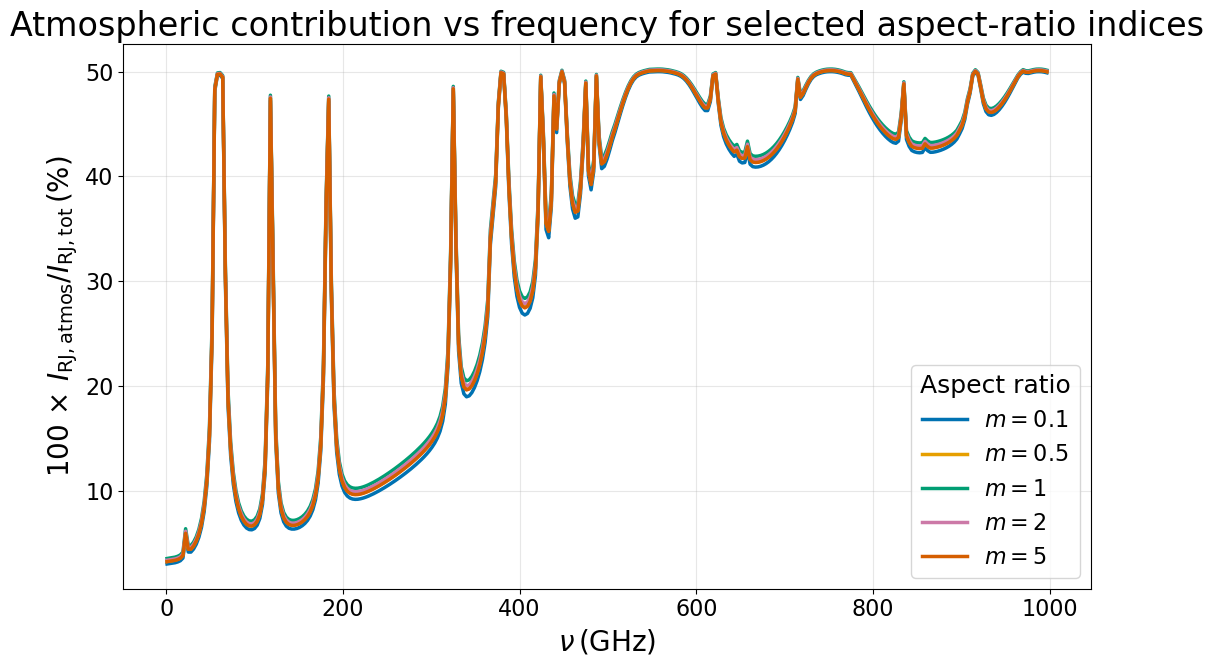

In [10]:
# Plot atmospheric fraction vs frequency for several chosen aspect-ratio indices
m_indices = [0, 1,2,  3, 4]  # Choose the m indices you want to compare

fig, ax = plt.subplots(figsize=(11, 7))

# High-contrast, colorblind-friendly palette for the different m indices
m_colors = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#D55E00', '#56B4E9']
if len(m_indices) > len(m_colors):
    m_colors = list(plt.cm.tab10(np.linspace(0, 1, len(m_indices))))

for idx, m_index in enumerate(m_indices):
    total = I_RJ_scattering_tot_earth_curv[:, 0, m_index]
    atmos = I_RJ_scattering_atmos_earth_curv[:, 0, m_index]
    pct_atm = np.where(total != 0, 100.0 * atmos / total, np.nan)

    ax.plot(
        frequency_ghz,
        pct_atm,
        color=m_colors[idx],
        linewidth=2.5,
        label=fr'$m={m[m_index]:.3g}$',
    )

ax.set_xlabel(r'$\nu\,\mathrm{(GHz)}$')
ax.set_ylabel(r'$100\,\times\,I_{\mathrm{RJ,atmos}}/I_{\mathrm{RJ,tot}}\,(\%)$')
ax.set_title('Atmospheric contribution vs frequency for selected aspect-ratio indices')
ax.grid(True, alpha=0.3)
ax.legend(title='Aspect ratio')
fig.tight_layout()

/pscratch/sd/v/valer/atmo3/notebooks/testing_class_ice_emisison/class_and_spt_emission.py:413: RuntimeWarning: overflow encountered in exp
  T_sky = T_mid * (1.0 - np.exp(-tau_above * m_sky))
/pscratch/sd/v/valer/atmo3/notebooks/testing_class_ice_emisison/class_and_spt_emission.py:413: RuntimeWarning: overflow encountered in multiply
  T_sky = T_mid * (1.0 - np.exp(-tau_above * m_sky))


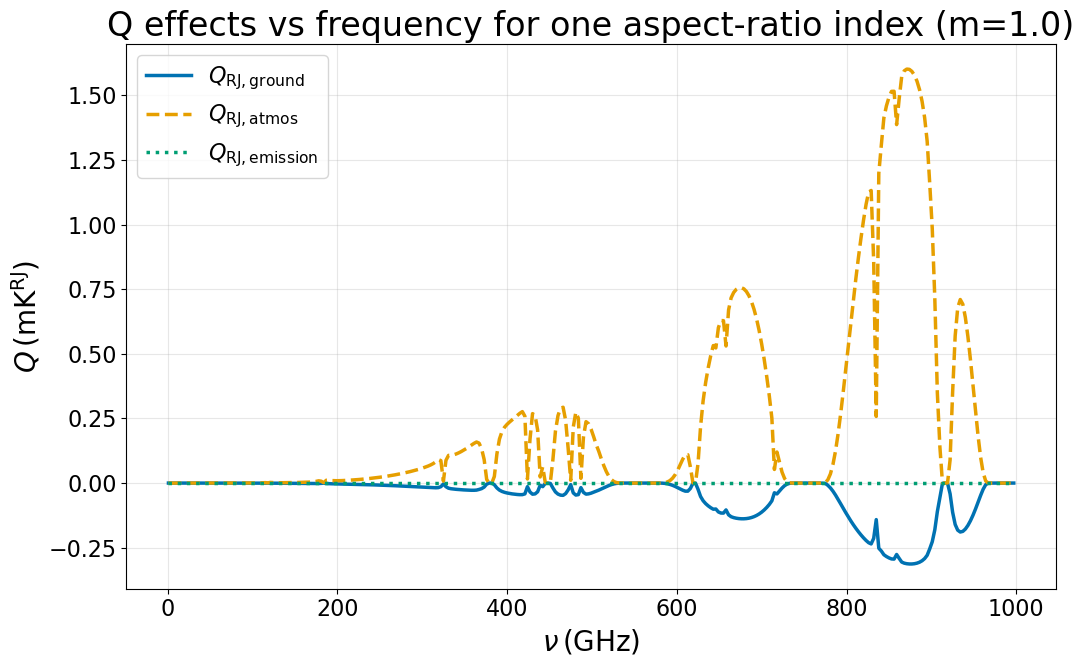

In [11]:
# Q-stokes study: reproduce the I calculation and plots for Stokes Q
Q_RJ_scattering_tot_earth_curv = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m, stokes_param='Q', consider_earth_curvature=True, consider_atmospheric_emission=True
)

Q_RJ_scattering_ground_earth_curv = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m, stokes_param='Q', consider_earth_curvature=True, consider_atmospheric_emission=False
)

Q_RJ_scattering_atmos_earth_curv = Q_RJ_scattering_tot_earth_curv - Q_RJ_scattering_ground_earth_curv

Q_RJ_emission = compute_T_RJ_ice2(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq,
    aspect_ratio=m, process='emission', stokes_param='Q'
)

# Plot each Q effect as a function of frequency for one chosen aspect-ratio index
m_index = 2  # Choose the aspect-ratio index you want to inspect

fig, ax = plt.subplots(figsize=(11, 7))

# High-contrast, colorblind-friendly palette
colors = ['#0072B2', '#E69F00', '#009E73']

# If the spectrum is larger than the palette, fall back to tab10
if len(colors) < 3:
    colors = list(plt.cm.tab10(np.linspace(0, 1, 3)))

effects = [
    (r'$Q_{\mathrm{RJ,ground}}$', Q_RJ_scattering_ground_earth_curv[:, 0, m_index], '-'),
    (r'$Q_{\mathrm{RJ,atmos}}$', Q_RJ_scattering_atmos_earth_curv[:, 0, m_index], '--'),
    (r'$Q_{\mathrm{RJ,emission}}$', Q_RJ_emission[:, 0, m_index], ':'),
]

for idx, (label, data, linestyle) in enumerate(effects):
    ax.plot(
        frequency_ghz,
        data * 1e3,
        color=colors[idx],
        linestyle=linestyle,
        linewidth=2.5,
        label=label,
    )

ax.set_xlabel(r'$\nu\,\mathrm{(GHz)}$')
ax.set_ylabel(r'$Q\,\mathrm{(mK}^{\mathrm{RJ}}\mathrm{)}$')
ax.set_title(f'Q effects vs frequency for one aspect-ratio index (m={m[m_index]})')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()


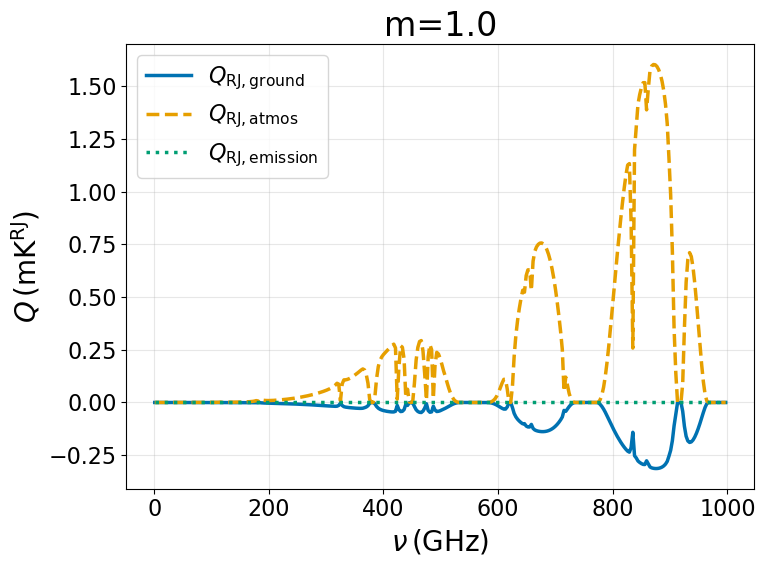

In [22]:
# Plot each Q effect as a function of frequency for one chosen aspect-ratio index
m_index = 2  # Choose the aspect-ratio index you want to inspect

fig, ax = plt.subplots(figsize=(8, 6))

# High-contrast, colorblind-friendly palette
colors = ['#0072B2', '#E69F00', '#009E73']

# If the spectrum is larger than the palette, fall back to tab10
if len(colors) < 3:
    colors = list(plt.cm.tab10(np.linspace(0, 1, 3)))

effects = [
    (r'$Q_{\mathrm{RJ,ground}}$', Q_RJ_scattering_ground_earth_curv[:, 0, m_index], '-'),
    (r'$Q_{\mathrm{RJ,atmos}}$', Q_RJ_scattering_atmos_earth_curv[:, 0, m_index], '--'),
    (r'$Q_{\mathrm{RJ,emission}}$', Q_RJ_emission[:, 0, m_index], ':'),
]

for idx, (label, data, linestyle) in enumerate(effects):
    ax.plot(
        frequency_ghz,
        data * 1e3,
        color=colors[idx],
        linestyle=linestyle,
        linewidth=2.5,
        label=label,
    )

ax.set_xlabel(r'$\nu\,\mathrm{(GHz)}$')
ax.set_ylabel(r'$Q\,\mathrm{(mK}^{\mathrm{RJ}}\mathrm{)}$')
ax.set_title(f'm={m[m_index]}')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

In [ ]:
# Plot each Q effect as a function of frequency for one chosen aspect-ratio index
m_index = 1  # Choose the aspect-ratio index you want to inspect

fig, ax = plt.subplots(figsize=(8, 6))

# High-contrast, colorblind-friendly palette
colors = ['#0072B2', '#E69F00', '#009E73']

# If the spectrum is larger than the palette, fall back to tab10
if len(colors) < 3:
    colors = list(plt.cm.tab10(np.linspace(0, 1, 3)))

effects = [
    (r'$Q_{\mathrm{RJ,ground}}$', Q_RJ_scattering_ground_earth_curv[:, 0, m_index], '-'),
    (r'$Q_{\mathrm{RJ,atmos}}$', Q_RJ_scattering_atmos_earth_curv[:, 0, m_index], '--'),
    (r'$Q_{\mathrm{RJ,emission}}$', Q_RJ_emission[:, 0, m_index], ':'),
]

for idx, (label, data, linestyle) in enumerate(effects):
    ax.plot(
        frequency_ghz,
        data * 1e3,
        color=colors[idx],
        linestyle=linestyle,
        linewidth=2.5,
        label=label,
    )

ax.set_xlabel(r'$\nu\,\mathrm{(GHz)}$')
ax.set_ylabel(r'$Q\,\mathrm{(mK}^{\mathrm{RJ}}\mathrm{)}$')
ax.set_title(f'm={m[m_index]}')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

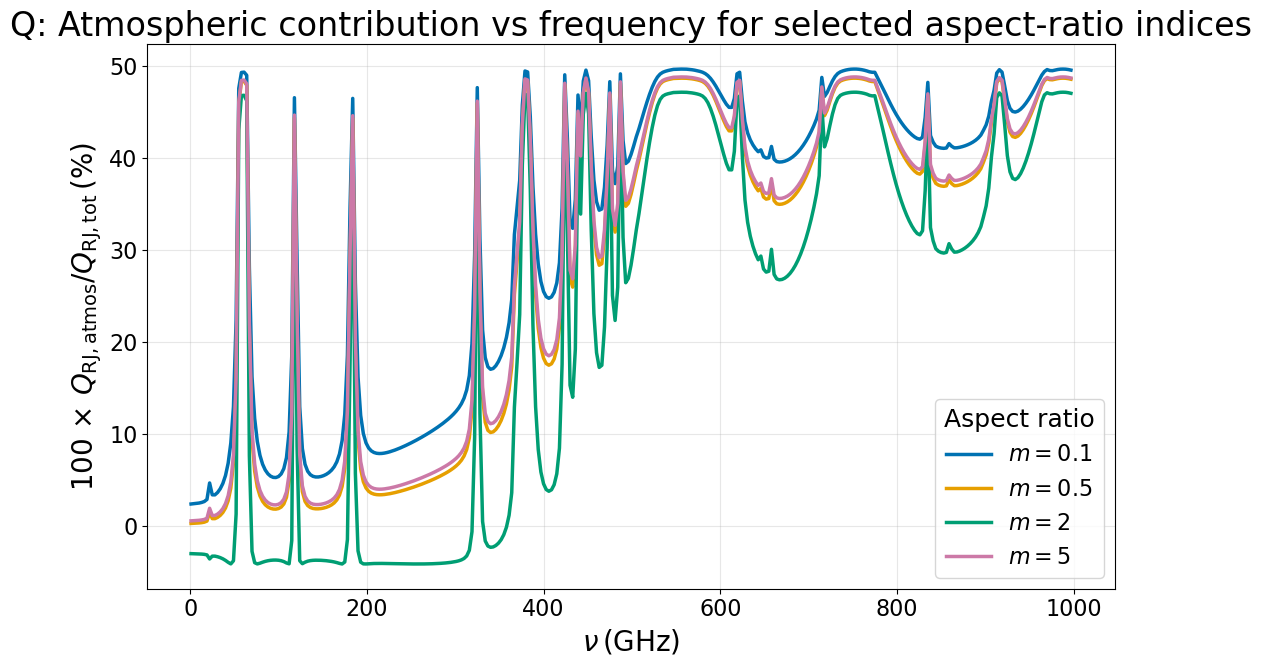

In [12]:
# Plot atmospheric fraction vs frequency for several chosen aspect-ratio indices
m_indices = [0, 1, 3, 4]  # Choose the m indices you want to compare

fig, ax = plt.subplots(figsize=(11, 7))

# High-contrast, colorblind-friendly palette for the different m indices
m_colors = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#D55E00', '#56B4E9']
if len(m_indices) > len(m_colors):
    m_colors = list(plt.cm.tab10(np.linspace(0, 1, len(m_indices))))

for idx, m_index in enumerate(m_indices):
    total = Q_RJ_scattering_tot_earth_curv[:, 0, m_index]
    atmos = Q_RJ_scattering_atmos_earth_curv[:, 0, m_index]
    pct_atm = np.where(total != 0, 100.0 * atmos / total, np.nan)

    ax.plot(
        frequency_ghz,
        pct_atm,
        color=m_colors[idx],
        linewidth=2.5,
        label=fr'$m={m[m_index]:.3g}$',
    )

ax.set_xlabel(r'$\nu\,\mathrm{(GHz)}$')
ax.set_ylabel(r'$100\,\times\,Q_{\mathrm{RJ,atmos}}/Q_{\mathrm{RJ,tot}}\,(\%)$')
ax.set_title('Q: Atmospheric contribution vs frequency for selected aspect-ratio indices')
ax.grid(True, alpha=0.3)
ax.legend(title='Aspect ratio')
fig.tight_layout()

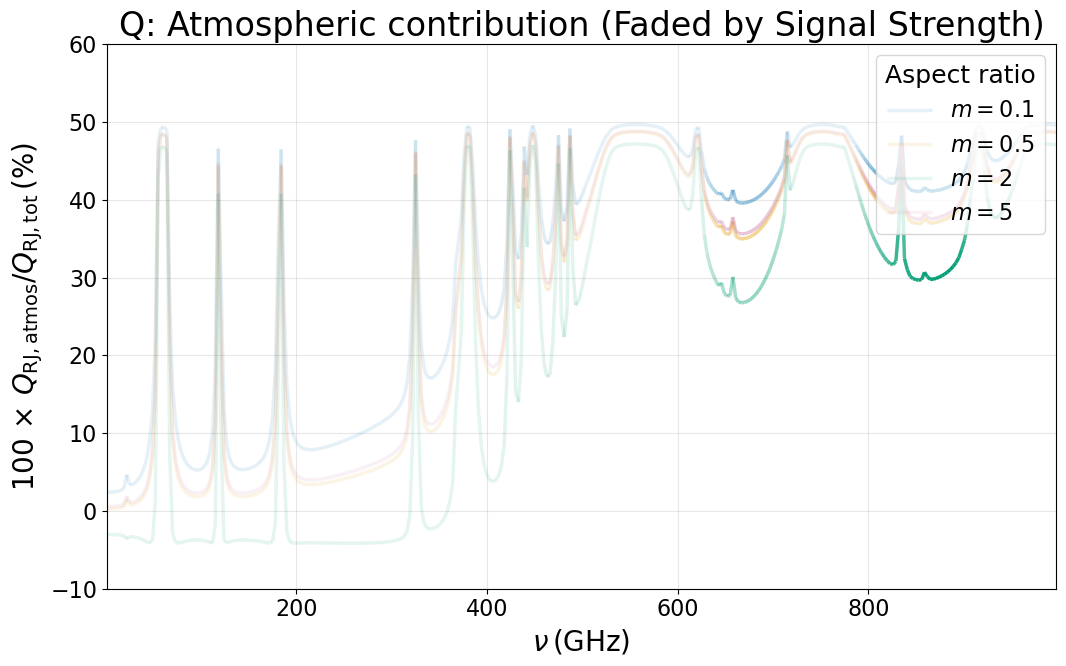

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors

m_indices = [0, 1, 3, 4] 
fig, ax = plt.subplots(figsize=(11, 7))

m_colors = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#D55E00', '#56B4E9']

for idx, m_index in enumerate(m_indices):
    total = Q_RJ_scattering_tot_earth_curv[:, 0, m_index]
    atmos = Q_RJ_scattering_atmos_earth_curv[:, 0, m_index]
    
    # Calculate percentage
    pct_atm = np.where(total != 0, 100.0 * atmos / total, np.nan)
    
    # Calculate normalized signal strength for alpha (transparency)
    # We use a floor of 0.1 so the line never completely disappears
    abs_signal = np.abs(total)
    norm_signal = np.clip(abs_signal / np.nanmax(abs_signal), 0.1, 1.0)
    
    # Create line segments (x, y) pairs
    points = np.array([frequency_ghz, pct_atm]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    # Create an RGBA color array for the segments based on signal strength
    base_color = mcolors.to_rgba(m_colors[idx])
    segment_colors = np.zeros((len(segments), 4))
    segment_colors[:, :3] = base_color[:3]
    segment_colors[:, 3] = (norm_signal[:-1] + norm_signal[1:]) / 2.0 # Average alpha of the two points
    
    # Create and add the LineCollection
    lc = LineCollection(segments, colors=segment_colors, linewidth=2.5, label=fr'$m={m[m_index]:.3g}$')
    ax.add_collection(lc)

ax.set_xlim(frequency_ghz.min(), frequency_ghz.max())
ax.set_ylim(-10, 60) # Adjust based on your data limits
ax.set_xlabel(r'$\nu\,\mathrm{(GHz)}$')
ax.set_ylabel(r'$100\,\times\,Q_{\mathrm{RJ,atmos}}/Q_{\mathrm{RJ,tot}}\,(\%)$')
ax.set_title('Q: Atmospheric contribution (Faded by Signal Strength)')
ax.grid(True, alpha=0.3)
ax.legend(title='Aspect ratio')
fig.tight_layout()
plt.show()

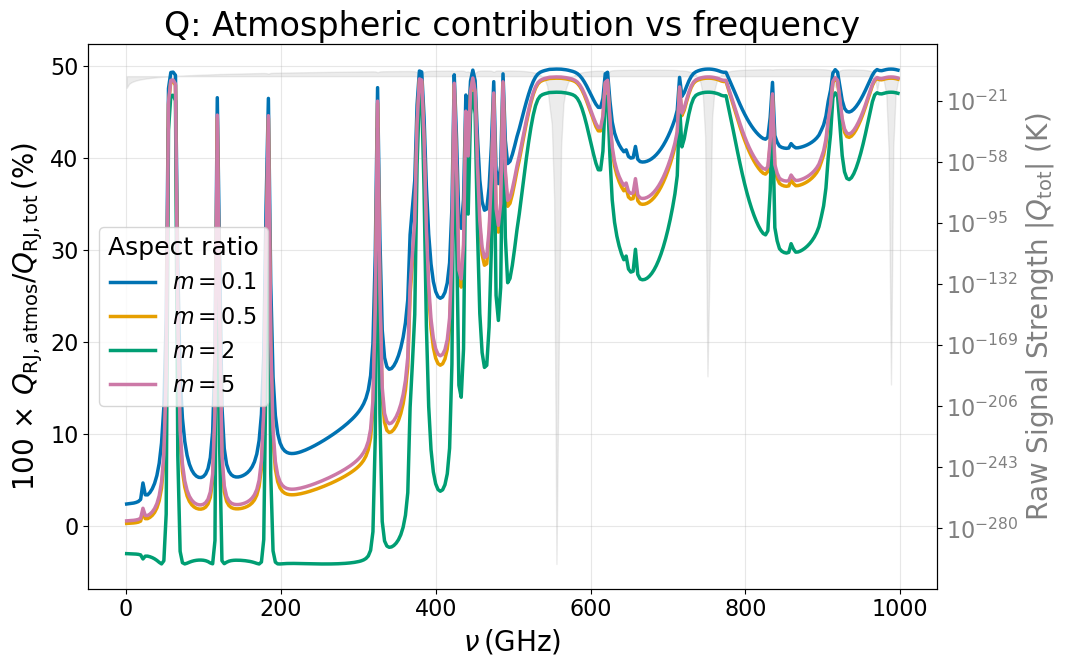

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

m_indices = [0, 1, 3, 4] 
fig, ax = plt.subplots(figsize=(11, 7))

m_colors = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#D55E00', '#56B4E9']

# 1. Add the Twin Axis for the background
ax2 = ax.twinx()

# Calculate a representative signal strength (e.g., the mean of all plotted m indices)
mean_abs_total = np.nanmean(np.abs(Q_RJ_scattering_tot_earth_curv[:, 0, m_indices]), axis=1)

# Plot the background shading
ax2.fill_between(frequency_ghz, 1e-6, mean_abs_total, color='gray', alpha=0.15, label='Mean $|Q_{tot}|$ Signal')
ax2.set_ylabel(r'Raw Signal Strength $|Q_{\mathrm{tot}}|$ (K)', color='gray')
ax2.set_yscale('log') # Log scale is highly recommended for Rayleigh scattering!
ax2
ax2.tick_params(axis='y', labelcolor='gray')

# Ensure the main axis is "on top" of the background shading
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)

# 2. Plot the main lines (Your original code)
for idx, m_index in enumerate(m_indices):
    total = Q_RJ_scattering_tot_earth_curv[:, 0, m_index]
    atmos = Q_RJ_scattering_atmos_earth_curv[:, 0, m_index]
    pct_atm = np.where(total != 0, 100.0 * atmos / total, np.nan)

    ax.plot(
        frequency_ghz, pct_atm,
        color=m_colors[idx], linewidth=2.5,
        label=fr'$m={m[m_index]:.3g}$',
    )

ax.set_xlabel(r'$\nu\,\mathrm{(GHz)}$')
ax.set_ylabel(r'$100\,\times\,Q_{\mathrm{RJ,atmos}}/Q_{\mathrm{RJ,tot}}\,(\%)$')
ax.set_title('Q: Atmospheric contribution vs frequency')
ax.grid(True, alpha=0.3)
ax.legend(title='Aspect ratio', loc='center left') # Moved so it doesn't overlap shading
fig.tight_layout()
plt.show()

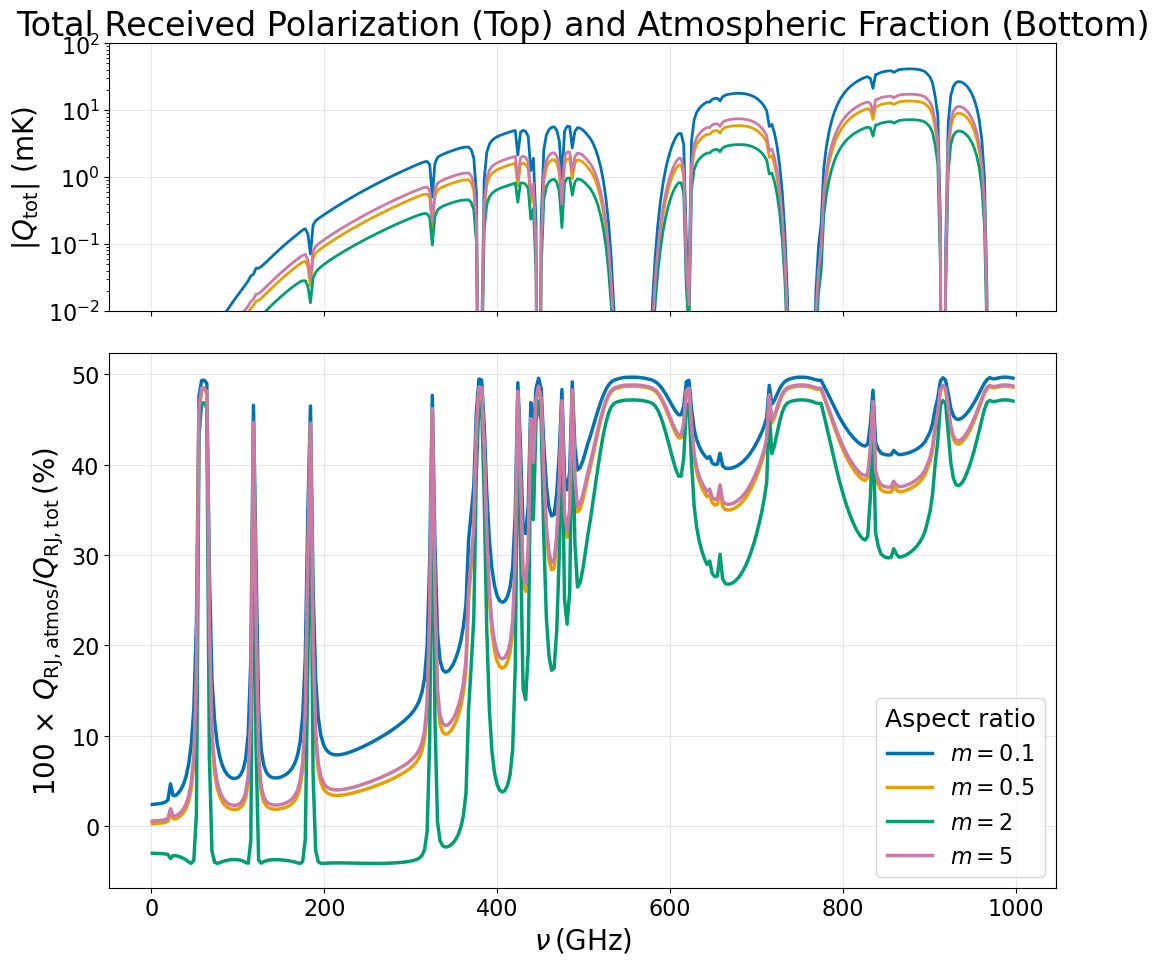

In [19]:
import numpy as np
import matplotlib.pyplot as plt

m_indices = [0, 1, 3, 4] 

# Create two stacked subplots sharing the X-axis
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 10), sharex=True, gridspec_kw={'height_ratios': [1, 2]})

m_colors = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#D55E00', '#56B4E9']

for idx, m_index in enumerate(m_indices):
    total = Q_RJ_scattering_tot_earth_curv[:, 0, m_index]
    atmos = Q_RJ_scattering_atmos_earth_curv[:, 0, m_index]
    
    # Calculate percentage
    pct_atm = np.where(total != 0, 100.0 * atmos / total, np.nan)

    # Top Panel: Absolute Total Signal
    ax_top.plot(
        frequency_ghz, np.abs(total) * 1e3,  # Convert to mK for better visibility
        color=m_colors[idx], linewidth=2.0
    )
    
    # Bottom Panel: Fractional Contribution
    ax_bot.plot(
        frequency_ghz, pct_atm,
        color=m_colors[idx], linewidth=2.5,
        label=fr'$m={m[m_index]:.3g}$'
    )

# Formatting Top Panel
ax_top.set_ylabel(r'$|Q_{\mathrm{tot}}|$ (mK)')
ax_top.set_title('Total Received Polarization (Top) and Atmospheric Fraction (Bottom)')
ax_top.set_ylim(1e-2, 1e2) # Adjust based on your data limits
ax_top.set_yscale('log') # Rayleigh scattering drops off rapidly, log scale is best here
ax_top.grid(True, alpha=0.3)

# Formatting Bottom Panel
ax_bot.set_xlabel(r'$\nu\,\mathrm{(GHz)}$')
ax_bot.set_ylabel(r'$100\,\times\,Q_{\mathrm{RJ,atmos}}/Q_{\mathrm{RJ,tot}}\,(\%)$')
ax_bot.grid(True, alpha=0.3)
ax_bot.legend(title='Aspect ratio')

fig.tight_layout()
plt.show()